In [129]:
from pathlib import Path
import sys
from dataclasses import dataclass

src_path = Path.cwd().parent / "src"
sys.path.insert(0, str(src_path))

from main import *
from scipy.linalg import expm
from scipy.optimize import nnls

In [119]:
def dissipator_from_builder(builder, jump_operator):
    """
    Construct the Liouville-space matrix D[L] using the user's
    existing LiouvillianBuilder and Jump classes.
    """
    zero_H = np.zeros(
        (builder.d, builder.d),
        dtype=np.complex128,
    )

    return builder.build(
        zero_H,
        [Jump(jump_operator, 1.0)],
    )

def annihilation_operator(dim: int) -> np.ndarray:
    """
    Harmonic-oscillator lowering operator in a truncated Fock basis

        |0>, |1>, ..., |dim-1>.

    Matrix elements:
        <m|a|n> = sqrt(n) delta_{m,n-1}.
    """
    if dim < 1:
        raise ValueError("dim must be at least 1.")

    return np.diag(
        np.sqrt(np.arange(1, dim, dtype=float)),
        k=1,
    ).astype(np.complex128)


def creation_operator(dim: int) -> np.ndarray:
    """Truncated harmonic-oscillator raising operator a†."""
    return annihilation_operator(dim).conj().T

def thermal_harmonic_oscillator_model(
    dim: int,
    omega: float,
    beta: float,
    gamma: float,
):
    """
    Construct a time-independent thermal harmonic-oscillator model.

    Master equation:

        drho/dt = -i[H, rho]
                  + gamma*(nbar + 1)*D[a](rho)
                  + gamma*nbar*D[a†](rho).
    """
    if dim < 2:
        raise ValueError("dim must be at least 2.")
    if omega <= 0.0:
        raise ValueError("omega must be positive.")
    if beta <= 0.0:
        raise ValueError("beta must be positive.")
    if gamma < 0.0:
        raise ValueError("gamma must be non-negative.")

    a = annihilation_operator(dim)
    adag = a.conj().T
    number = adag @ a

    # The omitted omega/2 identity only contributes a global phase
    # and therefore drops out of [H, rho].
    H = omega * number

    nbar = 1.0 / np.expm1(beta * omega)

    def H_of_t(t):
        return H

    def jumps_of_t(t):
        return [
            Jump(a, gamma * (nbar + 1.0)),
            Jump(adag, gamma * nbar),
        ]

    model = LindbladModel2LS(H_of_t, jumps_of_t)
    return model, a, adag, nbar

In [130]:
# Generate code to plot and test the evolution with the counterdiabatic Lindbladian

@dataclass
class OverallAGPData:
    parameter_grid: np.ndarray
    rho_ss: np.ndarray
    drho_ds: np.ndarray

    # H_AGP(s) = sum_j x_j(s) H_j
    x: np.ndarray

    # Dissipative AGP: sum_k gamma_k(s) D[L_k]
    gamma: np.ndarray

    residual_norm_squared: np.ndarray
    unitary_residual_norm_squared: np.ndarray
    x_norm_squared: np.ndarray
    gamma_norm_squared: np.ndarray


def precompute_overall_agp(
    parameter_grid,
    rho_and_derivative,
    hamiltonians,
    jump_operators,
    *,
    lam_unitary=0.0,
    lam_dissipative=0.0,
    rcond=1e-12,
):
    """
    Precompute the sequential variational AGP on a parameter grid.

    At each s:

      1. Fit H_AGP(s) = sum_j x_j(s) H_j using a signed,
         Moore-Penrose / regularised least-squares fit.

      2. Fit positive dissipative rates gamma_k(s) to cancel the
         residual left by the Hamiltonian fit.
    """
    parameter_grid = np.asarray(parameter_grid, dtype=float)

    rho_list, derivative_list = [], []
    x_list, gamma_list = [], []

    total_residual_list = []
    unitary_residual_list = []
    x_norm_list = []
    gamma_norm_list = []

    for s in parameter_grid:
        rho_ss, drho_ds = rho_and_derivative(s)

        x, gamma, residual_total, details = fit_overall_agp(
            rho_ss=rho_ss,
            partial_s_rho_ss=drho_ds,
            hamiltonians=hamiltonians,
            jump_operators=jump_operators,
            lam_unitary=lam_unitary,
            lam_dissipative=lam_dissipative,
            rcond=rcond,
            return_details=True,
        )

        rho_list.append(rho_ss)
        derivative_list.append(drho_ds)
        x_list.append(x)
        gamma_list.append(gamma)

        total_residual_list.append(
            details["residual_total_norm_squared"]
        )
        unitary_residual_list.append(
            details["residual_unitary_norm_squared"]
        )
        x_norm_list.append(
            details["unitary"]["x_norm_squared"]
        )
        gamma_norm_list.append(
            details["dissipative"]["gamma_norm_squared"]
        )

    return OverallAGPData(
        parameter_grid=parameter_grid,
        rho_ss=np.asarray(rho_list),
        drho_ds=np.asarray(derivative_list),
        x=np.asarray(x_list),
        gamma=np.asarray(gamma_list),
        residual_norm_squared=np.asarray(total_residual_list),
        unitary_residual_norm_squared=np.asarray(
            unitary_residual_list
        ),
        x_norm_squared=np.asarray(x_norm_list),
        gamma_norm_squared=np.asarray(gamma_norm_list),
    )


def interpolate_coefficients(grid, coefficient_grid, s):
    """Linearly interpolate a coefficient vector at parameter value s."""
    return np.array([
        np.interp(s, grid, coefficient_grid[:, j])
        for j in range(coefficient_grid.shape[1])
    ])


def build_overall_agp_model(
    bare_H_of_t,
    bare_jumps_of_t,
    parameter_of_t,
    parameter_dot_of_t,
    agp_data,
    hamiltonians,
    jump_operators,
):
    """
    Build the CD-corrected model

        H(t) = H_bare(t) + sdot(t) sum_j x_j(s(t)) H_j,

    with jumps

        bare jumps + sdot(t) sum_k gamma_k(s(t)) D[L_k].

    This follows the convention used in `fit_overall_agp`:

        d_s rho_ss + i[H_AGP, rho_ss]
        - sum_k gamma_k D[L_k](rho_ss) ~ 0.
    """
    hamiltonians = np.asarray(hamiltonians, dtype=np.complex128)

    def H_of_t(t):
        s = parameter_of_t(t)
        sdot = parameter_dot_of_t(t)

        x = interpolate_coefficients(
            agp_data.parameter_grid,
            agp_data.x,
            s,
        )

        H_agp = np.tensordot(x, hamiltonians, axes=(0, 0))
        return bare_H_of_t(t) + sdot * H_agp

    def jumps_of_t(t):
        jumps = list(bare_jumps_of_t(t))

        s = parameter_of_t(t)
        sdot = parameter_dot_of_t(t)

        gamma = interpolate_coefficients(
            agp_data.parameter_grid,
            agp_data.gamma,
            s,
        )

        for L, rate in zip(jump_operators, sdot * gamma):
            if rate < -1e-12:
                raise ValueError(
                    "The dissipative CD rate became negative. "
                    "This is not a GKSL generator."
                )

            if rate > 1e-14:
                jumps.append(Jump(L, rate))

        return jumps

    return LindbladModel2LS(H_of_t, jumps_of_t)


In [121]:
dim = 20
omega = 1.0
beta = 2.0
gamma = 0.1

model, a, adag, nbar = thermal_harmonic_oscillator_model(
    dim=dim,
    omega=omega,
    beta=beta,
    gamma=gamma,
)

builder = LiouvillianBuilder(dim=dim)

H = model.H(0.0)
jumps = model.jumps(0.0)

L_total = builder.build(H, jumps)

print("Thermal occupation:", nbar)
print("Hamiltonian shape:", H.shape)
print("Liouvillian shape:", L_total.shape)

20
Thermal occupation: 0.15651764274966565
Hamiltonian shape: (20, 20)
Liouvillian shape: (400, 400)


## 1. Example of tuning the temperature for CD
First we want to consider varying $\beta$. The best way to do this is to use the analytic solution. Then, once we find that, we want to consider
$$\partial_s \rho_{ss} = \mathcal{A}_s \rho_{ss}.$$

### QHO where we tune temperature of the bath
This example is particularly simple since 
1. We know the analytic solution.
2. We also have no rotation of the steady state, only dissipative part.

In [132]:
#---------------------
# Caclulate the target
#----------------------

N = adag @ a

rho_unnormalized = expm(-beta * omega * N)
rho_ss = rho_unnormalized / np.trace(rho_unnormalized)

mean_N = np.trace(N @ rho_ss).real

#Target for what action of superoperator should give.
drho_ss_dbeta = -omega * (
    N - mean_N * np.eye(N.shape[0])
) @ rho_ss

#---------------------
# Variational Calculation
#---------------------
hamiltonians = [N]
jump_operators = [a,a@a,adag@a]

x, gamma, residual_total, details = fit_overall_AGP(
    rho_ss,
    drho_ss_dbeta,
    hamiltonians,
    jump_operators,
    lam_unitary=0.0,
    lam_dissipative=10**(-12),
    return_details=True,
)

print("Fitted Hamiltonian coefficients (x):", x)
print("Fitted dissipative coefficients (gamma):", gamma)
print("Residual norm squared:", details["residual_total_norm_squared"])

# print(gamma)
# print("Residual norm squared:", results["residual_norm_squared"])
# print("Gamma norm squared:", results["gamma_norm_squared"])
# print("Theory value of gamma if we just have 'a':", omega/(1-np.exp(-beta*omega)))

Fitted Hamiltonian coefficients (x): [0.]
Fitted dissipative coefficients (gamma): [1.15651764 0.         0.        ]
Residual norm squared: 6.17979223089371e-23


In [134]:
def approx_CD_trajectory(
    model,
    s_of_t,
    times,
    hamiltonians,
    jump_operators,
    *,
    dim=2,
    vec_order="F",
    lam_unitary=0.0,
    lam_dissipative=0.0,
):
    """
    Evolve the instantaneous steady state under the approximate
    counterdiabatic Lindbladian

        L_CD(t) = L(s(t)) + sdot(t) A_s.

    Here `model` is interpreted as a function of s:
        model.H(s)
        model.jumps(s)

    The AGP is calculated variationally on the supplied time grid
    and linearly interpolated between grid points.

    Returns
    -------
    t : ndarray
        Time grid.

    traj : Trajectory
        Trajectory object from LindbladEvolver.

    rho_t : ndarray, shape (nt, d, d)
        CD-evolved density matrices.

    rho_ss_t : ndarray, shape (nt, d, d)
        Instantaneous steady states rho_ss(s(t)).
    """

    # --------------------------------------------------
    # Grid and builder
    # --------------------------------------------------

    t = np.asarray(times, dtype=float)
    s_t = np.array([s_of_t(tt) for tt in t], dtype=float)

    builder = LiouvillianBuilder(
        dim=dim,
        vec_order=vec_order,
    )

    # --------------------------------------------------
    # Instantaneous steady states
    # --------------------------------------------------

    rho_ss_t = np.array([
        get_steady_state(builder, model, s)
        for s in s_t
    ])

    # partial_s rho_ss and sdot
    drho_ds_t = np.gradient(
        rho_ss_t,
        s_t,
        axis=0,
        edge_order=2 if len(t) >= 3 else 1,
    )

    sdot_t = np.gradient(
        s_t,
        t,
        edge_order=2 if len(t) >= 3 else 1,
    )

    # --------------------------------------------------
    # Variational AGP on the grid
    # --------------------------------------------------

    H_agp_t = []
    gamma_agp_t = []

    for rho_ss, drho_ds in zip(rho_ss_t, drho_ds_t):

        _, gamma, _, details = fit_overall_AGP(
            rho_ss=rho_ss,
            partial_s_rho_ss=drho_ds,
            hamiltonians=hamiltonians,
            jump_operators=jump_operators,
            lam_unitary=lam_unitary,
            lam_dissipative=lam_dissipative,
            return_details=True,
        )

        H_agp_t.append(details["H_agp"])
        gamma_agp_t.append(gamma)

    H_agp_t = np.asarray(H_agp_t)
    gamma_agp_t = np.asarray(gamma_agp_t)

    # --------------------------------------------------
    # Linear interpolation
    # --------------------------------------------------

    def interp(tt, values):
        if tt <= t[0]:
            return values[0]
        if tt >= t[-1]:
            return values[-1]

        k = np.searchsorted(t, tt) - 1
        a = (tt - t[k]) / (t[k + 1] - t[k])

        return (1 - a) * values[k] + a * values[k + 1]

    # --------------------------------------------------
    # CD model:
    #
    # H -> H + sdot H_AGP
    # gamma_j -> sdot gamma_j
    # --------------------------------------------------

    def H_CD_of_t(tt):

        s = s_of_t(tt)
        sdot = interp(tt, sdot_t)
        H_agp = interp(tt, H_agp_t)

        return model.H(s) + sdot * H_agp

    def jumps_CD_of_t(tt):

        s = s_of_t(tt)
        sdot = interp(tt, sdot_t)
        gamma = interp(tt, gamma_agp_t)

        # Original physical jumps
        jumps = list(model.jumps(s))

        # Counterdiabatic dissipative terms
        jumps += [
            Jump(L, sdot * g)
            for L, g in zip(jump_operators, gamma)
        ]

        return jumps

    CD_model = LindbladModel2LS(
        H_CD_of_t,
        jumps_CD_of_t,
    )

    # --------------------------------------------------
    # Start in rho_ss(s(t0)) and use existing evolver
    # --------------------------------------------------

    rho0 = rho_ss_t[0]

    evolver = LindbladEvolver(
        CD_model,
        builder,
    )

    traj = evolver.simulate(
        rho0,
        t,
    )

    # Density matrices along the actual CD trajectory
    rho_t = np.array([
        traj.rho(k)
        for k in range(len(traj.t))
    ])

    return t, traj, rho_t, rho_ss_t

10


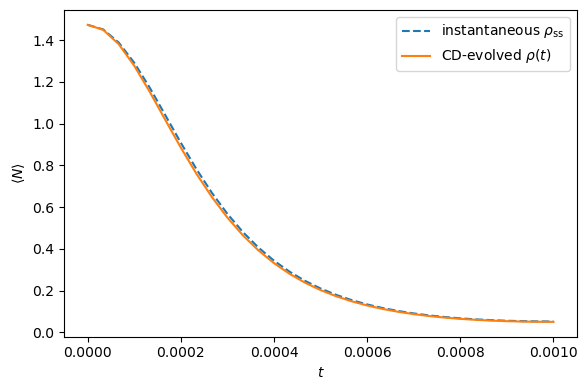

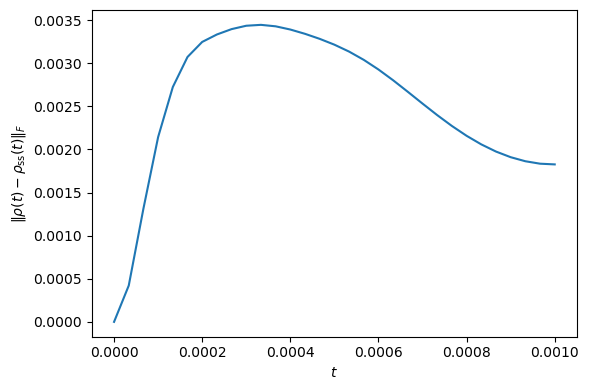

In [165]:
# ============================================================
# Approximate-CD trajectory for thermal harmonic oscillator
# ============================================================

# --------------------
# Easy parameters to tune
# --------------------
dim = 10
omega = 1.0
kappa = 1.0

beta0 = 0.5
beta1 = 3.0

tau = 0.001          # protocol duration: smaller = faster
nsteps = 31       # number of AGP/evolution grid points

# --------------------
# Operators
# --------------------
a = annihilation_operator(dim)
adag = creation_operator(dim)
N = adag @ a

# --------------------
# Physical Lindblad model L(beta)
# --------------------
def H_of_beta(beta):
    return omega * N

def jumps_of_beta(beta):
    nbar = 1.0 / (np.exp(beta * omega) - 1.0)

    return [
        Jump(a,    kappa * (nbar + 1.0)),
        Jump(adag, kappa * nbar),
    ]

model = LindbladModel2LS(
    H_of_beta,
    jumps_of_beta,
)

# --------------------
# Protocol beta(t)
# --------------------
def beta_of_t(t):
    return beta0 + 0.5 * (beta1 - beta0) * (
        1.0 - np.cos(np.pi * t / tau)
    )
#Linear ramp
# def beta_of_t(t):
#     return beta0 + (beta1 - beta0) * t / tau

times = np.linspace(0.0, tau, nsteps)

# --------------------
# Variational AGP basis
# --------------------
hamiltonians = [N]#N]
jump_operators = [
    a,
    a@a,
]

# --------------------
# Run approximate-CD evolution
# --------------------
t, traj, rho_t, rho_ss_t = approx_CD_trajectory(
    model,
    beta_of_t,
    times,
    hamiltonians,
    jump_operators,
    dim=dim,
    lam_unitary=0.0,
    lam_dissipative=1e-12,
)

# ============================================================
# Compare actual trajectory with instantaneous steady state
# ============================================================

N_actual = np.array([
    np.trace(rho @ N).real
    for rho in rho_t
])

N_ss = np.array([
    np.trace(rho @ N).real
    for rho in rho_ss_t
])

plt.figure(figsize=(6, 4))

plt.plot(t, N_ss, "--", label=r"instantaneous $\rho_{\rm ss}$")
plt.plot(t, N_actual, label=r"CD-evolved $\rho(t)$")

plt.xlabel(r"$t$")
plt.ylabel(r"$\langle N\rangle$")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: direct density-matrix tracking error
tracking_error = np.array([
    np.linalg.norm(rho - rho_ss, ord="fro")
    for rho, rho_ss in zip(rho_t, rho_ss_t)
])

plt.figure(figsize=(6, 4))
plt.plot(t, tracking_error)

plt.xlabel(r"$t$")
plt.ylabel(r"$\|\rho(t)-\rho_{\rm ss}(t)\|_F$")
plt.tight_layout()
plt.show()

In [131]:
a = annihilation_operator(dim)
adag = creation_operator(dim)
Nop = adag @ a
H_bare = omega * Nop

hamiltonians = [
    Nop,
    a @ a + adag @ adag,
    1j * (adag @ adag - a @ a),
]

jump_operators = [
    a @ a,
    adag @ a,
]

n_times = 100
beta_i=0.3
beta_f=1.5

parameter_grid = np.linspace(beta_i, beta_f, n_times)
beta_of_t, betadot_of_t = linear_beta_schedule(beta_i, beta_f, T)

agp_data = precompute_overall_agp(
    parameter_grid=parameter_grid,
    rho_and_derivative=lambda beta: thermal_rho_ss_and_derivative(
        dim, omega, beta
    ),
    hamiltonians=hamiltonians,
    jump_operators=jump_operators,
    lam_unitary=0.0,
    lam_dissipative=0.0,
)

def bare_H_of_t(t):
    return H_bare

def bare_jumps_of_t(t):
    nbar = 1.0 / np.expm1(beta_of_t(t) * omega)
    return [
        Jump(a, bath_gamma * (nbar + 1.0)),
        Jump(adag, bath_gamma * nbar),
    ]

bare_model = LindbladModel2LS(
    bare_H_of_t,
    bare_jumps_of_t,
)

agp_model = build_overall_agp_model(
    bare_H_of_t=bare_H_of_t,
    bare_jumps_of_t=bare_jumps_of_t,
    parameter_of_t=beta_of_t,
    parameter_dot_of_t=betadot_of_t,
    agp_data=agp_data,
    hamiltonians=hamiltonians,
    jump_operators=jump_operators,
)

NameError: name 'beta_i' is not defined

In [116]:
# ============================================================
# Small helpers
# ============================================================

def thermal_rho_ss_and_derivative(dim, omega, beta):
    """
    Return rho_ss(beta) and d rho_ss / d beta for the truncated
    harmonic oscillator with H = omega * N.
    """
    a = annihilation_operator(dim)
    adag = creation_operator(dim)
    Nop = adag @ a

    rho_unnormalized = expm(-beta * omega * Nop)
    rho_ss = rho_unnormalized / np.trace(rho_unnormalized)

    mean_N = np.trace(Nop @ rho_ss).real
    drho_dbeta = -omega * (Nop - mean_N * np.eye(dim)) @ rho_ss

    # enforce Hermiticity numerically
    rho_ss = 0.5 * (rho_ss + rho_ss.conj().T)
    drho_dbeta = 0.5 * (drho_dbeta + drho_dbeta.conj().T)

    return rho_ss, drho_dbeta


def nearest_index(grid, x):
    idx = np.searchsorted(grid, x)
    if idx <= 0:
        return 0
    if idx >= len(grid):
        return len(grid) - 1
    if abs(x - grid[idx - 1]) <= abs(grid[idx] - x):
        return idx - 1
    return idx


def purity_of_rho(rho):
    return np.real(np.trace(rho @ rho))


def mean_number_of_rho(rho, Nop):
    return np.real(np.trace(Nop @ rho))


def trace_distance(rho, sigma):
    """
    Trace distance T(rho,sigma) = 1/2 ||rho-sigma||_1.
    Since rho-sigma is Hermitian, use eigvalsh.
    """
    delta = 0.5 * ((rho - sigma) + (rho - sigma).conj().T)
    eigs = np.linalg.eigvalsh(delta)
    return 0.5 * np.sum(np.abs(eigs))


def linear_beta_schedule(beta_i, beta_f, T):
    slope = (beta_f - beta_i) / T

    def beta_of_t(t):
        t_clip = min(max(float(t), 0.0), T)
        return beta_i + slope * t_clip

    def betadot_of_t(t):
        # valid because we only simulate on [0,T]
        return slope

    return beta_of_t, betadot_of_t


# ============================================================
# Precompute the variational CD coefficients on a time grid
# ============================================================

def precompute_variational_cd_data(
    dim,
    omega,
    t_eval,
    beta_of_t,
    jump_operators,
    lam=0.0,
):
    """
    For each time in t_eval:
      - build rho_ss(beta(t))
      - build d rho_ss / d beta
      - fit A_beta(rho_ss) ~ d rho_ss / d beta
    """
    rho_ss_list = []
    drho_dbeta_list = []
    gamma_cd_list = []
    residuals = []
    gamma_norms = []

    for t in t_eval:
        beta_t = beta_of_t(t)
        rho_ss, drho_dbeta = thermal_rho_ss_and_derivative(
            dim, omega, beta_t
        )

        gamma_cd, details = fit_dissipative_agp_nnls(
            rho_ss,
            drho_dbeta,
            jump_operators,
            lam=lam,
            return_details=True,
            verbose=False,
        )

        rho_ss_list.append(rho_ss)
        drho_dbeta_list.append(drho_dbeta)
        gamma_cd_list.append(gamma_cd)
        residuals.append(details["residual_norm_squared"])
        gamma_norms.append(details["gamma_norm_squared"])

    return {
        "rho_ss": np.array(rho_ss_list),
        "drho_dbeta": np.array(drho_dbeta_list),
        "gamma_cd": np.array(gamma_cd_list),
        "residuals": np.array(residuals),
        "gamma_norms": np.array(gamma_norms),
    }


# ============================================================
# Build bare and CD-corrected time-dependent models
# ============================================================

def build_bare_and_cd_models(
    dim,
    omega,
    bath_gamma,
    beta_of_t,
    betadot_of_t,
    t_eval,
    jump_operators,
    gamma_cd_grid,
):
    a = annihilation_operator(dim)
    adag = creation_operator(dim)
    Nop = adag @ a
    H = omega * Nop

    def H_of_t(t):
        return H

    def bare_jumps_of_t(t):
        beta_t = beta_of_t(t)
        nbar = 1.0 / np.expm1(beta_t * omega)

        return [
            Jump(a, bath_gamma * (nbar + 1.0)),
            Jump(adag, bath_gamma * nbar),
        ]

    def cd_jumps_of_t(t):
        jumps = bare_jumps_of_t(t)

        idx = nearest_index(t_eval, float(t))
        prefactor = betadot_of_t(t)
        gamma_cd = gamma_cd_grid[idx]

        # CD contribution: dot(beta) * sum_j gamma_j(beta) D[L_j]
        for L, g in zip(jump_operators, gamma_cd):
            rate = prefactor * g
            if abs(rate) > 0.0:
                jumps.append(Jump(L, rate))

        return jumps

    bare_model = LindbladModel2LS(H_of_t, bare_jumps_of_t)
    cd_model = LindbladModel2LS(H_of_t, cd_jumps_of_t)

    return bare_model, cd_model


# ============================================================
# Main plotting function
# ============================================================

def plot_variational_cd_performance(
    dim=12,
    omega=1.0,
    bath_gamma=1.0,
    beta_i=0.3,
    beta_f=1.5,
    T=2.0,
    n_times=250,
    lam=0.0,
    *,
    jump_operators=None,
    verbose=True,
):
    """
    Compare bare evolution against variational-CD-corrected evolution.

    Notes
    -----
    - Choose beta_f > beta_i so that dot(beta) > 0, otherwise the
      CD rates dot(beta)*gamma_j become negative and the correction
      is no longer GKSL.
    - If jump_operators is None, uses [a@a, adag@a].
    """

    if beta_f <= beta_i:
        raise ValueError(
            "For this GKSL CD construction, choose beta_f > beta_i "
            "so that dot(beta) > 0."
        )

    a = annihilation_operator(dim)
    adag = creation_operator(dim)
    Nop = adag @ a

    if jump_operators is None:
        # IMPORTANT: use a @ a, not a**2
        jump_operators = [a @ a, adag @ a]

    t_eval = np.linspace(0.0, T, n_times)
    beta_of_t, betadot_of_t = linear_beta_schedule(beta_i, beta_f, T)

    # Precompute the fitted CD coefficients gamma_j(beta(t))
    cd_data = precompute_variational_cd_data(
        dim=dim,
        omega=omega,
        t_eval=t_eval,
        beta_of_t=beta_of_t,
        jump_operators=jump_operators,
        lam=lam,
    )

    if verbose:
        print("Mean fit residual:", np.mean(cd_data["residuals"]))
        print("Max fit residual :", np.max(cd_data["residuals"]))
        print("Mean ||gamma||^2 :", np.mean(cd_data["gamma_norms"]))
        print("First fitted gamma vector:", cd_data["gamma_cd"][0])
        print("Last fitted gamma vector :", cd_data["gamma_cd"][-1])

    # Build bare and CD models
    bare_model, cd_model = build_bare_and_cd_models(
        dim=dim,
        omega=omega,
        bath_gamma=bath_gamma,
        beta_of_t=beta_of_t,
        betadot_of_t=betadot_of_t,
        t_eval=t_eval,
        jump_operators=jump_operators,
        gamma_cd_grid=cd_data["gamma_cd"],
    )

    builder = LiouvillianBuilder(dim=dim)
    evolver_bare = LindbladEvolver(bare_model, builder)
    evolver_cd = LindbladEvolver(cd_model, builder)

    # Initial state: exact initial instantaneous steady state
    rho0 = cd_data["rho_ss"][0]

    traj_bare = evolver_bare.simulate(rho0, t_eval)
    traj_cd = evolver_cd.simulate(rho0, t_eval)

    # Extract observables and distances
    rho_ss_t = cd_data["rho_ss"]

    n_ss = np.zeros(n_times)
    pur_ss = np.zeros(n_times)

    n_bare = np.zeros(n_times)
    pur_bare = np.zeros(n_times)
    dist_bare = np.zeros(n_times)

    n_cd = np.zeros(n_times)
    pur_cd = np.zeros(n_times)
    dist_cd = np.zeros(n_times)

    for k in range(n_times):
        rho_target = rho_ss_t[k]
        rho_bare = traj_bare.rho(k)
        rho_cd_k = traj_cd.rho(k)

        # small Hermitisation to suppress numerical noise
        rho_bare = 0.5 * (rho_bare + rho_bare.conj().T)
        rho_cd_k = 0.5 * (rho_cd_k + rho_cd_k.conj().T)

        n_ss[k] = mean_number_of_rho(rho_target, Nop)
        pur_ss[k] = purity_of_rho(rho_target)

        n_bare[k] = mean_number_of_rho(rho_bare, Nop)
        pur_bare[k] = purity_of_rho(rho_bare)
        dist_bare[k] = trace_distance(rho_bare, rho_target)

        n_cd[k] = mean_number_of_rho(rho_cd_k, Nop)
        pur_cd[k] = purity_of_rho(rho_cd_k)
        dist_cd[k] = trace_distance(rho_cd_k, rho_target)

    # ========================================================
    # Plot
    # ========================================================
    fig, ax = plt.subplots(1, 2, figsize=(11.0, 4.4), constrained_layout=True)

    # Left panel: path in observable space
    ax[0].plot(
        n_ss, pur_ss,
        "--",
        linewidth=2.2,
        label="instantaneous steady state",
    )
    ax[0].plot(
        n_bare, pur_bare,
        linewidth=2.2,
        label="bare evolution",
    )
    ax[0].plot(
        n_cd, pur_cd,
        linewidth=2.2,
        label="with variational CD",
    )

    ax[0].scatter([n_ss[0]], [pur_ss[0]], s=35, zorder=5, label="start")
    ax[0].scatter([n_ss[-1]], [pur_ss[-1]], s=35, zorder=5, label="end")

    ax[0].set_xlabel(r"$\langle N \rangle$")
    ax[0].set_ylabel(r"${\rm Tr}(\rho^2)$")
    ax[0].set_title("Path in state space")
    ax[0].legend(frameon=False)

    # Right panel: distance from instantaneous steady state
    ax[1].plot(
        t_eval, dist_bare,
        linewidth=2.2,
        label="bare evolution",
    )
    ax[1].plot(
        t_eval, dist_cd,
        linewidth=2.2,
        label="with variational CD",
    )

    ax[1].set_xlabel(r"$t$")
    ax[1].set_ylabel(r"$\frac{1}{2}\|\rho(t)-\rho_{\rm ss}(t)\|_1$")
    ax[1].set_title("Deviation from instantaneous steady state")
    ax[1].legend(frameon=False)

    plt.show()

    return {
        "t_eval": t_eval,
        "rho_ss_t": rho_ss_t,
        "traj_bare": traj_bare,
        "traj_cd": traj_cd,
        "gamma_cd_grid": cd_data["gamma_cd"],
        "fit_residuals": cd_data["residuals"],
        "fit_gamma_norms": cd_data["gamma_norms"],
        "dist_bare": dist_bare,
        "dist_cd": dist_cd,
        "n_ss": n_ss,
        "pur_ss": pur_ss,
        "n_bare": n_bare,
        "pur_bare": pur_bare,
        "n_cd": n_cd,
        "pur_cd": pur_cd,
    }

Mean fit residual: 0.008255874664658146
Max fit residual : 0.0779015111894696
Mean ||gamma||^2 : 3.8957076741352332
First fitted gamma vector: [2.98521788]
Last fitted gamma vector : [1.28721642]
12


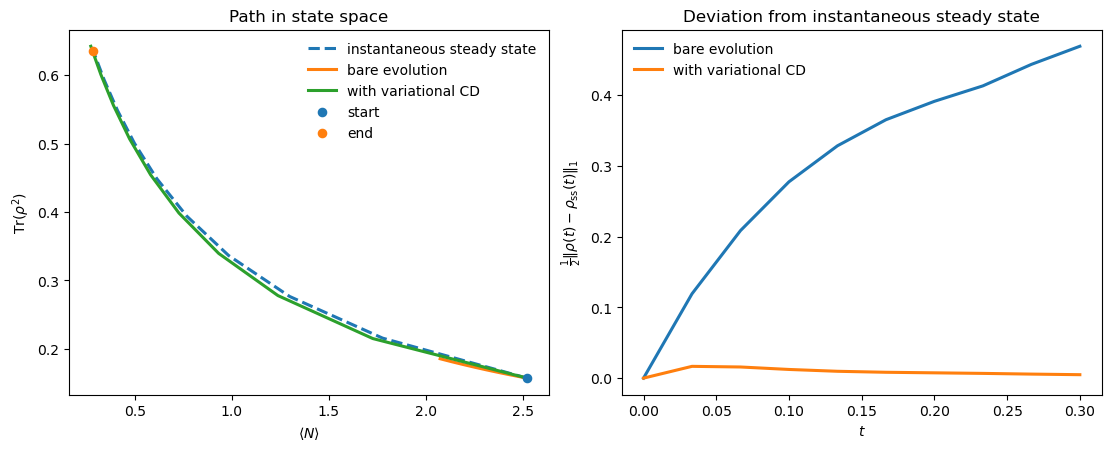

In [117]:
dim = 12
omega = 1.0
bath_gamma = 1.0

a = annihilation_operator(dim)
adag = creation_operator(dim)

results = plot_variational_cd_performance(
    dim=dim,
    omega=omega,
    bath_gamma=bath_gamma,
    beta_i=0.3,
    beta_f=1.5,   # choose beta_f > beta_i so dot(beta) > 0
    T=0.3,
    n_times=10,
    lam=0.0,
    jump_operators=[a],   # NOT a**2
    verbose=True,
)

### 2LS case

In [74]:
rho_ss=np.array([[1,0],[0,1]])/2
drho_ss=np.array([[1,0],[0,-1]])

jump_operators = [Pauli.sz, Pauli.sx, Pauli.sx+1.j*Pauli.sy]
    
gamma, results = fit_dissipative_agp_nnls(
    rho_ss,
    drho_ss,
    jump_operators,
    lam=0.0,
    return_details=True,
)

print(gamma)
print("Residual norm squared:", results["residual_norm_squared"])
print("Gamma norm squared:", results["gamma_norm_squared"])

[0.  0.  0.5]
Residual norm squared: 0.0
Gamma norm squared: 0.25


### Old hardcoded version

In [ ]:
#----------------------
# Calculate the AGP variationally
#----------------------
def fit_single_dissipator(
    builder,
    rho,
    drho,
    jump_operator,
):
    """
    Solve

        min_c ||drho - c D[L](rho)||_F

    for a real scalar c.
    """
    D = dissipator_from_builder(
        builder,
        jump_operator,
    )

    rho_vec = builder.vec(rho)
    target = builder.vec(drho)

    # Direction in operator space generated by D[L]
    direction = D @ rho_vec

    denominator = np.vdot(
        direction,
        direction,
    ).real

    if denominator < 1e-15:
        raise ValueError(
            "D[L](rho) is numerically zero, so the coefficient "
            "cannot be determined."
        )

    coefficient = (
        np.vdot(direction, target).real
        / denominator
    )

    fitted_target = coefficient * direction
    residual = target - fitted_target

    return {
        "coefficient": coefficient,
        "dissipator": D,
        "superoperator": coefficient * D,
        "fitted_derivative": builder.mat(fitted_target),
        "residual": builder.mat(residual),
        "residual_norm": np.linalg.norm(residual),
        "relative_residual": (
            np.linalg.norm(residual)
            / np.linalg.norm(target)
        ),
    }

result = fit_single_dissipator(
    builder,
    rho_ss,
    drho_ss_dbeta,
    a,
)

print("Optimal coefficient:")
print(result["coefficient"])

print("Residual norm:")
print(result["residual_norm"])

print("Relative residual:")
print(result["relative_residual"])


(1-9.860761315262648e-32j)


/var/folders/h3/s252cnjs1fg5q_2y8x3vh8mr0000gp/T/ipykernel_83807/2655252996.py:4: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(rhoss_num)))


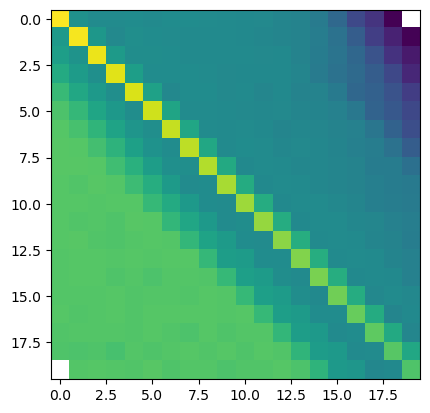

/var/folders/h3/s252cnjs1fg5q_2y8x3vh8mr0000gp/T/ipykernel_83807/2655252996.py:8: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(rhoss)))


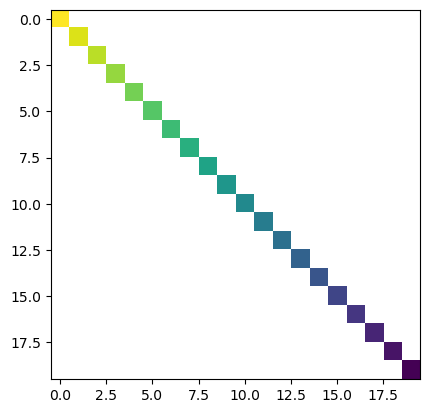

Error in numerics vs. analytics for rho_ss
4.3798335016052187e-14


In [36]:
#Calculate the steady state numerically
rhoss_num=get_steady_state(builder, model, 0.0)
print(np.trace(rhoss_num))
plt.imshow(np.log(np.abs(rhoss_num)))
plt.show()
M=expm(-beta*omega*(adag@a))
rhoss=M/np.trace(M)
plt.imshow(np.log(np.abs(rhoss)))
plt.show()
print("Error in numerics vs. analytics for rho_ss")
print(np.sum(np.abs(rhoss_num-rhoss)))